In [1]:
import numpy as np
from numpy.linalg import eigh
from scipy.linalg import eigh, expm

from qiskit import QuantumCircuit,  QuantumRegister, ClassicalRegister, AncillaRegister, transpile, qasm2
from qiskit.circuit import Parameter
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.circuit.library import PauliEvolutionGate, hamiltonian_variational_ansatz
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.synthesis import SuzukiTrotter
from qiskit.primitives import BackendEstimatorV2 as Estimator

import os

import quimb.tensor as qtn
import quimb as qu

import csv
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as tck

In this Jupyter notebook, I use the quimb tensor network package to approximate long chains, and then use the properties of MPS to evolve and measure the state in order to calculate the dichotomic time correlator $C_Q(t) = \langle \psi |\frac{1}{2} \{e^{i H t} Q e^{ - i H t}, Q \} | \psi \rangle $

In [ ]:
def apply_gate(psi, measure_opp = 'Z'):
    """Applies the measure_opp gate to psi and returns a new psi"""
    
    L = len(psi.tensors)
    psi_Q = psi.copy()
    
    if len(measure_opp) == 1:
        Opp =qu.pauli(measure_opp)
        # Apply X gate to site n
        psi_Q = psi_Q.gate(Opp, L//2, contract='swap+split')

    elif measure_opp == "X_even":

        for i in range(0, L, 2):
            Opp = qu.pauli('X')
            psi_Q = psi_Q.gate(Opp, i, contract='swap+split')

    elif measure_opp == "Z_tot":

        for i in range(0, L, 2):
            Opp = qu.pauli('X')
            psi_Q = psi_Q.gate(Opp, i, contract='swap+split')

    else: raise ValueError("Pick a preconfigured operator type")

    return psi_Q


def DMRG_ising_GS(L, J = 1, h = 1):
    """Approxmate the ground state of the Ising model.
    Returns state, energy, and quimb.tensor.tn1d.tebd.LocalHam1D 
    class object suitable for TEBD evolution.
    H_i = -J Z_i Z_{i+1} - h X_i      where operators are unitary Pauli"""
    H_ising = qtn.SpinHam1D(S=1/2, cyclic=False)
    H_ising += -4.0 * J , 'Z', 'Z'
    H_ising += -2.0 * h , 'X'
    H_MPO = H_ising.build_mpo( L )
    H_ising_LocalHam = H_ising.build_local_ham( L )

    #run the DMRG procedure
    dmrg = qtn.DMRG2(H_MPO)
    dmrg.solve(max_sweeps=20, verbosity=0, cutoffs = 1e-09 )

    #call the ground state as a tensor network
    return dmrg.state, dmrg.energy, H_ising_LocalHam

def DMRG_Anderson_GS(L, t = 1,  eps  = -1, U = 1, mu = 0):
    """Approimates the ground state of the 1D Anderson
    impurity model. Returns state, energy, and quimb.tensor.tn1d.tebd.LocalHam1D 
    class object suitable for TEBD evolution.
    After JW transformation, Anderson Hamiltonian is 
    H = H_bath + H_imp 
    H_bath =- (t/2) (X_i X_{i + 2} + Y_i Y_{i + 2})
    H_imp_sig = eps n_sig + U n_up n_dn
    The 4-basis Hilbert space decomposes into two 2-basis Hilber spaces corresponding
    to spin channels"""

    H_AIM = qtn.LocalHam1D(2 * L, cyclic= False, H2={})

    #initialize the operators
    I = np.eye(2)
    X = qu.pauli('X')
    Y = qu.pauli('Y')
    Z = qu.pauli('Z')

    #build Hamiltonian
    #hopping
    hop = -(t/2) * ( np.kron(X, X) + np.kron(Y, Y))
    for i in range(2 * L - 2):
        H_AIM[i,  i + 2] += hop

    #impurity
    imp_site = L if L %2 ==0 else L +1

    #on-site potential
    pot = (eps/2 - U/4) * (Z)
    H_AIM[imp_site] += pot
    H_AIM[imp_site + 1] += pot
    for i in range(2 * L):
        H_AIM[i] += (mu/2) * Z

    #Hubbard
    hub = (U/4) * np.kron(Z, Z)
    H_AIM[imp_site, imp_site+1] += hub

    #convert to MPO
    H_MPO = H_AIM.build_mpo()

    #run DMRG procedure
    dmrg = qtn.DMRG2(H_MPO)
    dmrg.solve(max_sweeps=20, verbosity=0, cutoffs = 1e-09 )
    
    return dmrg.state, dmrg.energy, H_AIM

def TFIM_DMRG_correlation(L, J = 1, h = 1, time_end = 2, time_step = 0.05, measure_opp = 'X', dt = 0.05, time_start = 0):
    """Calcuates C_Q(t) for ground state of Ising Hamiltonian 
    for t in time_range and outputs an array of C_Q(t). """
    
    #call the ground state as a tensor network
    psi0, E0, H_ising_LocalHam = DMRG_ising_GS(L, J = J, h = h)

    #apply the measurement gate
    psi_Q = apply_gate(psi0, measure_opp = measure_opp)

    #The evolution is given by \exp(- i H t) | \psi >
    #time evolve for every time in time_range
    tebd = qtn.TEBD( psi_Q, H_ising_LocalHam, dt=dt  )

    correlation_C = []
    #eliminate machine-level precision error
    time_range = [round(t, 4) for t in np.arange(time_start, time_end, time_step)]
    for t in time_range:
        tebd.update_to(T = t, progbar = False)
        psi_t = tebd.pt
        psi_t = apply_gate(psi_t, measure_opp = measure_opp)
        Cor_C = psi0.H @ psi_t
        Cor_C *= np.exp(1j * E0 * t)
        Cor_C = np.real(Cor_C)
        correlation_C += [Cor_C]

    return time_range,  correlation_C

def TFIM_DMRG_LG_K(L, J = 1, h = 1, time_end = 2, time_step = 0.05, measure_opp = 'X', dt = 0.05):
    """Calculates the Legget-Garg correlation K = 2C(t) - C(2t)"""
    
    #Calculates C values from 0 to time_end
    times_1, leg_1 = TFIM_DMRG_correlation(L, J = J, h = h, time_end = time_end, time_step = time_step, measure_opp = measure_opp , dt = dt)
    #Calculates only the extra C values needed to calculate K
    times_2, leg_2 = TFIM_DMRG_correlation(L, J = J, h = h, time_end = 2 * time_end, time_start = time_end  ,time_step = 2* time_step, measure_opp = measure_opp , dt = dt)
    time_tot = times_1 + times_2
    cor_tot = leg_1 + leg_2

    #padding the data lists makes calculating K easier
    times_2 = [item for pair in zip(times_2, [100] * len(times_2)) for item in pair]
    leg_2 = [item for pair in zip( leg_2, [100] * len(leg_2)) for item in pair]

    cor_tot = leg_1 + leg_2

    K_lst = []
    # K = 2C(t) - C(2t)
    for i in range(len(times_1)):
        K_lst += [cor_tot[i] * 2 - cor_tot[2 * i]]
        
    return times_1, K_lst


In [ ]:
def op_on_site(op, site, L):
    I = np.eye(2, dtype=complex)

    if op =="Z":
        ops = [I] * L
        ops[site] = np.array([
        [1, 0],
        [0, -1]], dtype=complex)
    if op =="X_even":
        X = np.array([
        [0, 1],
        [1, 0] ], dtype=complex)
        ops =  [I] * L
        for i in range(0, L, 2):
            ops[i] = X
    
    out = ops[0]
    for A in ops[1:]:
        out = np.kron(out, A)

    return out

def TFIM_Exact_correlation(L, J = 1, h = 1, time_end = 2, time_step = 0.05, measure_opp = 'X', dt = 0.05, time_start = 0):
    """Calcuates C_Q(t) for ground state of Ising Hamiltonian 
    for t in time_range and outputs an array of C_Q(t). """

    #call the ground state as a tensor network
    H = qu.ham_ising(L , jz = -4.0 * J, bx = -2.0 * h)
    evals, evecs = eigh(H)  

    E0 = evals[0]
    psi0 = evecs[:, 0]

    #apply the measurement gate
    Zmid = op_on_site(measure_opp, L//2, L)
    phi = Zmid @ psi0

    # overlaps <n|Z|0>
    amps = evecs.conj().T @ phi
    # weights |<n|Z|0>|^2
    weights = np.abs(amps)**2

    # excitation energies
    dE = evals - E0

    time_range = [round(t, 4) for t in np.arange(time_start, time_end, time_step)]

    correlation_C = np.exp(
      -1j * np.outer(time_range, dE)
    ) @ weights

    return time_range,  list(np.real(correlation_C))

def TFIM_Exact_LG_K(L, J = 1, h = 1, time_end = 2, time_step = 0.05,  measure_opp = 'X_even', dt = 0.05):
    """Calculates the Legget-Garg correlation K = 2C(t) - C(2t)"""
    
    #Calculates C values from 0 to time_end
    times_1, leg_1 = TFIM_Exact_correlation(L, J = J, h = h, time_end = time_end, time_step = time_step, measure_opp = measure_opp , dt = dt)
    #Calculates only the extra C values needed to calculate K
    times_2, leg_2 = TFIM_Exact_correlation(L, J = J, h = h, time_end = 2 * time_end, time_start = time_end  ,time_step = 2* time_step, measure_opp = measure_opp , dt = dt)
    
    #padding the data lists makes calculating K easier
    times_2 = [item for pair in zip(times_2, [100] * len(times_2)) for item in pair]
    leg_2 = [item for pair in zip( leg_2, [100] * len(leg_2)) for item in pair]

    cor_tot = leg_1 + leg_2

    K_lst = []
    # K = 2C(t) - C(2t)
    for i in range(len(times_1)):
        K_lst += [cor_tot[i] * 2 - cor_tot[2 * i]]
        
    return times_1, K_lst


We also want the quantum Fisher information

In [127]:
def Quantum_Fisher_Exact( J, h, L, Qop):
    '''calculates the Quantum Fisher information with respect to an operator Q given the state in the Hlbert space, the Hamiltonian, and the operator Q'''
    Ham = qu.ham_ising(L , jz = -4.0 * J, bx = -2.0 * h)
    eig_values, eig_vectors = eigh(Ham)
    psi = eig_vectors[0]

    op_on_site(Qop, L//2, L)
    QFI = 4 * ( 1.0 - (psi @ (Qop @ psi))**2)

    return QFI


def Quantum_Fisher_DMRG( J, h, L, Qop):
    """Calculates the quantum Fisher information of the ground state approximated by DMRG"""
    psi0, E0, LocalHam = DMRG_ising_GS(L, J = J, h = h)
    psiQ = apply_gate(psi0, measure_opp = Qop)

    QFI = 4 * ( 1.0 - np.abs((psi0 @ psiQ))**2)

    return QFI


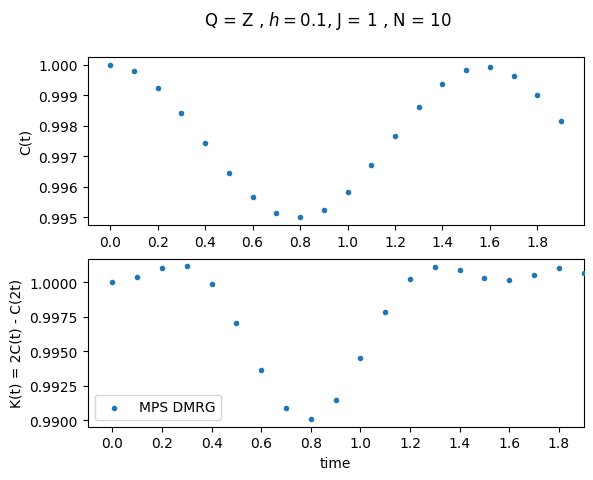

In [ ]:
chain_len = 10
J = .1
h = 1
op = "Z"
step = .1
t_end = 2
psi = "GS"
layers = 20
PBC = False


fig, ax = plt.subplots(2)
"""
#generate quantum circuit data
layer = "layers" + str(layers)
csv_path = os.getcwd() + "/data/" + "L"+str(chain_len) + 'time'+ str(t_end * 2) + 'd' + str( step)+ "J" + str(J) + "h" + str(h) +str(op) + "psi" + psi + layer +'PBC' + str(PBC) + '.csv'

with open(csv_path, newline='') as f:
    reader = csv.reader(f)
    [time_range, dta, delta_psi, delta_E] = [[float(x) for x in row] for row in reader]
    
half_len = len(dta)//2
dta_K_Qis = [2 * dta[j] - dta[2 * j] for j in range(half_len) ]

ax[1].scatter(time_range[:half_len]  , dta_K_Qis ,  marker= ".", label = "VQE Circuit\n $\\delta\\psi = $" + str(round(delta_psi[0],3))+ "\n $\\delta E = $" + str(round(delta_E[0],3))   , zorder = 3)
ax[0].scatter(time_range  , dta ,  marker= ".", label = "VQE_Circuit" , zorder = 3)

#Generate Exact Diagonalization data
times_E, dta_K_E = TFIM_Exact_LG_K(chain_len, J = J, h= h, measure_opp = op, time_step = step/2, time_end = t_end)
times_E, dta_C_E = TFIM_Exact_correlation(chain_len, J = J, h= h,  measure_opp = op, time_step = step/2, time_end = t_end)

ax[0].scatter( times_E  , dta_C_E ,  marker= ".", label = "Exact" , zorder = 3)
ax[1].scatter(times_E, dta_K_E ,  marker= ".", label = "Exact"   , zorder = 3)
"""
#Generate tensor network data
times, dta_K = TFIM_DMRG_LG_K(chain_len, J = J, h= h,  measure_opp = op, time_step = step, time_end = t_end)
times, dta_C = TFIM_DMRG_correlation(chain_len, J = J, h= h,  measure_opp = op, time_step = step, time_end = t_end)

ax[0].scatter( times  , dta_C ,  marker= ".", label = "MPS DMRG" , zorder = 3)
ax[1].scatter(times, dta_K ,  marker= ".", label = "MPS DMRG"   , zorder = 3)


#classical bound
#ax[1].axhline( y=1.5, color="0.9", linestyle = "--")
#ax[1].axhline( y=QFI_bound, color="0.9", linestyle = "--", label = "$1/8(F_Q) + \\langle (S^z_0 e^{i \\pi S^z_1}S^z_2)^2\\rangle$")

fig.suptitle("Q = " + op +" , $h = $" + str(h) + ", J = " + str(J) +" , N = " + str(chain_len))
ax[0].xaxis.set_major_locator(tck.MultipleLocator(base = t_end/10))
ax[1].xaxis.set_major_locator(tck.MultipleLocator(base = t_end/10))
plt.xlabel("time")
ax[0].set(ylabel = "C(t)")
plt.xlim( (-1.0 * times[1], times[-1] ))
ax[1].set(ylabel = "K(t) = 2C(t) - C(2t)")
#plt.ylim((0.9,1.6))
plt.xlim((-1.0 * times[1], times[-1] ))
plt.title("")
plt.legend()

plt.show()

Use the plots below to calculate the maximum end time needed to find the maximum LG_K value. For X_even, an adequate estimation of a good t_end is t_end $= 1.3  \sqrt{J}/ (L  ^{ min(J, 1)})$.

When the operator is just a local Z, the time which maximizes K is less dependent on the chain length and t_end = 0.4

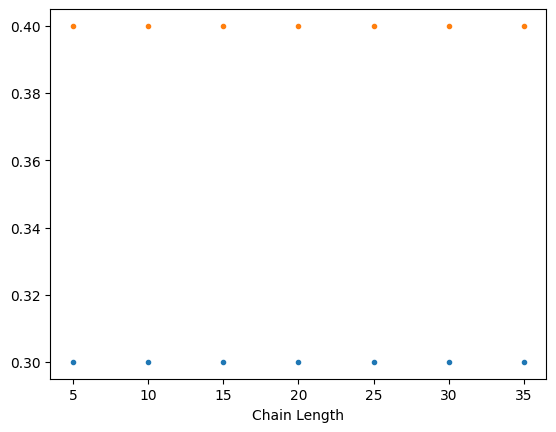

In [170]:
chain_len = 40
J = 1
h = 1

op = "Z"
step = .05
t_end = 1
Ls = range(5,chain_len, 5)

fig, ax = plt.subplots(1)

times_max=[]
for i in range(5,chain_len, 5):
#Generate DMRG data
    times, dta_K = TFIM_DMRG_LG_K(i, J = J, h= h, measure_opp = op, time_step = step, time_end = t_end)

    times_max.append(times[dta_K.index(max(dta_K))])
ax.scatter(Ls , times_max ,  marker= ".", label = ""   , zorder = 3)
ax.scatter(Ls , [.4 for i in Ls ] ,  marker= ".", label = ""   , zorder = 3)

ax.xaxis.set_major_locator(tck.MultipleLocator(base = 5))
plt.xlabel("Chain Length")

plt.show()

Now let's look at long chains using DMRG and plot the bound of the QFI and the QFI approximated by DMRG.

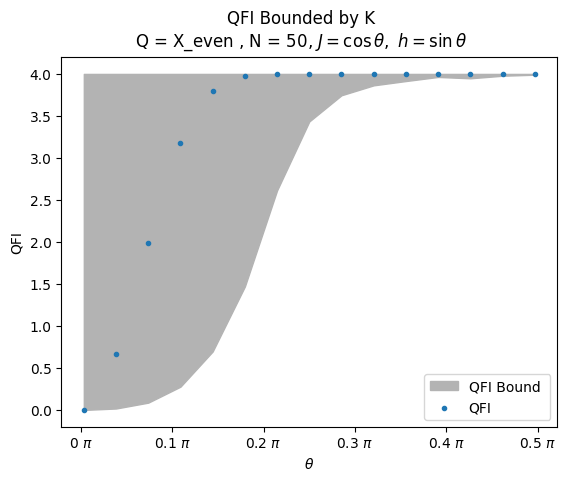

In [178]:
chain_len = 50
op = "X_even"
t_end = 2 * np.sqrt(J)* .65/ (chain_len** min(J, 1))
0.4
step  = t_end/ 40
num_points = 15

theta_range = np.linspace(.01, np.pi/2- .01, num_points)

fig, ax = plt.subplots(1)

LG_bound = []
QFI =[]
for theta in theta_range:
    #Generate LG_K lower bound
    J, h = np.sin(theta), np.cos(theta)
    times, dta_K = TFIM_DMRG_LG_K(chain_len, J = J, h= h,  measure_opp = op, time_step = step, time_end = t_end)
    max_K = max(dta_K)
    LG_bound += [8 * max(0, (max_K -1))]

    #Generate QFI
    QFI += [Quantum_Fisher_DMRG( J, h, chain_len, op)]



ax.fill_between(theta_range/ np.pi, LG_bound, 4 ,  color = '.7', label = "QFI Bound "  )
ax.scatter(theta_range/ np.pi, QFI, marker = '.', label = "QFI", zorder = 3)

fig.suptitle("QFI Bounded by K\nQ = " + op +" , N = " + str(chain_len) + ", $J = \\cos\\theta,~h = \\sin\\theta$")
ax.xaxis.set_major_formatter(tck.FormatStrFormatter("%g $\\pi$"))
plt.xlabel("$\\theta$")
ax.set(ylabel = "QFI")
#plt.ylim((0.9,1.6))
plt.legend()

plt.show()

In [179]:
#Save plot
fig.savefig("C:\\Users\\ianro\\Documents\\Research\\Quantum_Metrology_AKLT\\Plots\\TFIM_L50_Xeven_QFI_Bound.png")

In [ ]:
chain_len = 10
num_points = 15

theta_range = np.linspace(.01, np.pi/2- .01, num_points)

fig, ax = plt.subplots(1)

gap = []
for theta in theta_range:
    #Generate LG_K lower bound
    J, h = np.sin(theta), np.cos(theta)
    H = qu.ham_ising(chain_len , jz = -4.0 * J, bx = -2.0 * h)
    evals, evecs = eigh(H)  

    E0 = evals[0]
    psi0 = evecs[:, 0]


    #Generate QFI
    QFI += [Quantum_Fisher_DMRG( J, h, chain_len, op)]



ax.fill_between(theta_range/ np.pi, LG_bound, 4 ,  color = '.7', label = "QFI Bound "  )
ax.scatter(theta_range/ np.pi, QFI, marker = '.', label = "QFI", zorder = 3)

fig.suptitle("QFI Bounded by K\nQ = " + op +" , N = " + str(chain_len) + ", $J = \\cos\\theta,~h = \\sin\\theta$")
ax.xaxis.set_major_formatter(tck.FormatStrFormatter("%g $\\pi$"))
plt.xlabel("$\\theta$")
ax.set(ylabel = "QFI")
#plt.ylim((0.9,1.6))
plt.legend()

plt.show()

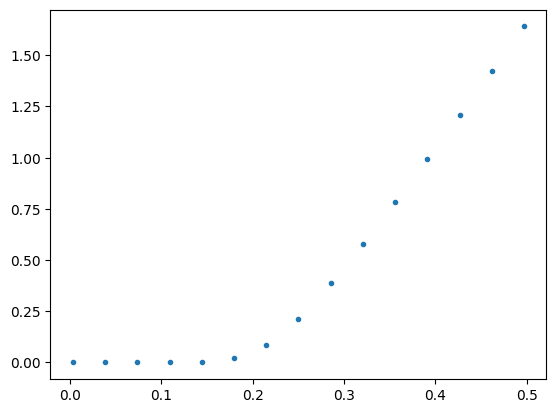

In [202]:
L = 11

theta_range = np.linspace(.01, np.pi/2- .01, num_points)
delE= []
for theta in theta_range:
    #Generate LG_K lower bound
    J, h = np.pi/4, theta

    H = qu.ham_ising(L , jz = -4.0 * J, bx = -2.0 * h)
    evals, evecs = eigh(H)  

    E0, E1 = evals[0:2]
    delE += [E1 - E0]

fig, ax = plt.subplots(1)
ax.scatter(theta_range/ np.pi, delE, marker = '.', label = "QFI", zorder = 3)


plt.show()



In [200]:
np.pi/4

0.7853981633974483